## Stage 0


In [1]:
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

DEVICE = "cpu"

### Regression

y = sin(x)


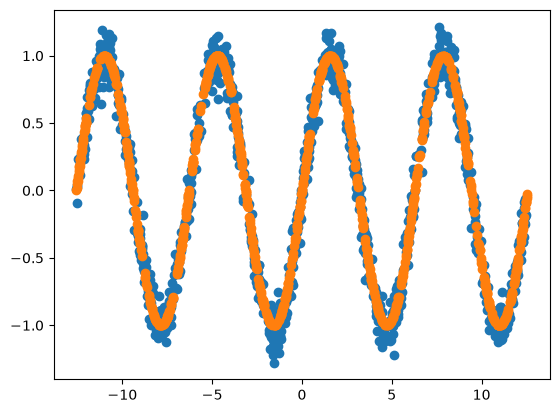

In [2]:
# Dataset
class RegressionDataset(Dataset):
    def __init__(self, n: int = 1000, add_noise: bool = True):
        self.n = n

        self.x = (torch.rand(self.n) - 0.5) * 8 * torch.pi
        self.x = self.x.unsqueeze(1)
        self.y = torch.sin(self.x)
        if add_noise:
            self.y += torch.normal(
                torch.zeros((self.n, 1)), torch.ones((self.n, 1)) * 0.1
            )  # noise

    def __len__(self):
        return self.n

    def __getitem__(self, index):
        return self.x[index,], self.y[index,]


ds_train = RegressionDataset(1000)
ds_test = RegressionDataset(1000, False)
dl_train = DataLoader(ds_train, batch_size=16, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=16, shuffle=True)


plt.scatter(ds_train.x, ds_train.y)
plt.scatter(ds_test.x, ds_test.y)

In [3]:
class RegressionModel(nn.Module):
    def __init__(self, n_hidden: int = 64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.Tanh(),
            # nn.ReLU(),
            nn.Linear(n_hidden, n_hidden // 2),
            nn.Tanh(),
            # nn.ReLU(),
            nn.Linear(n_hidden // 2, 1)
        )
        
    def forward(self, x):
        return self.model(x)

100%|██████████| 10000/10000 [01:12<00:00, 137.69it/s]


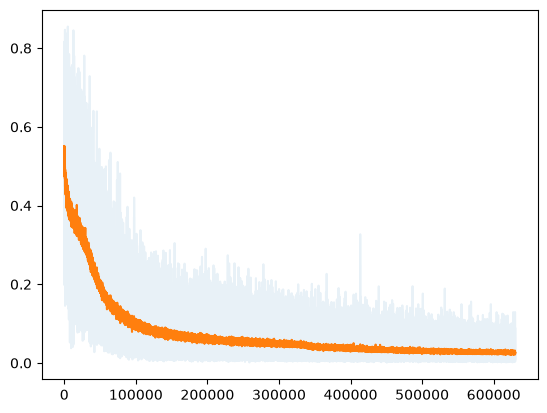

In [4]:
model = RegressionModel()
loss_fn = nn.MSELoss()
optim = torch.optim.SGD(model.parameters(), lr=1e-3)

# 
model.train()
losses = []
for i in tqdm(range(10000)): # epochs
    for X, y in dl_train:
        optim.zero_grad()
        pred = model.forward(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optim.step()
        losses.append(loss.item())

rolling_avg = torch.tensor(losses)
rolling_avg = rolling_avg.view(1, 1, -1)
rolling_avg = torch.nn.functional.avg_pool1d(rolling_avg, kernel_size=50, stride=1)
rolling_avg = rolling_avg.view(-1)
plt.plot(losses, alpha=0.1)
plt.plot(rolling_avg)


In [5]:

# torch.convolution(torch.tensor(losses), weight=torch.ones(10), bias=0)

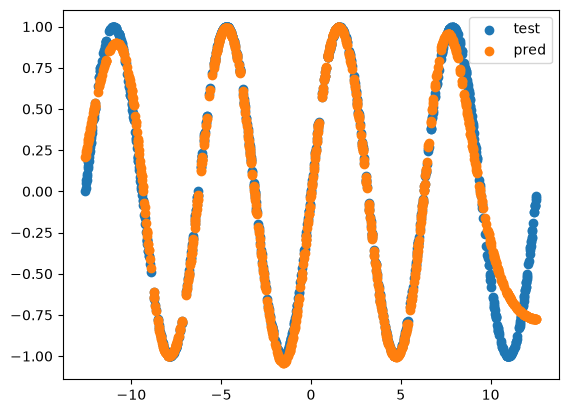

In [6]:
model.eval()
y_pred = model.forward(ds_test.x)
plt.scatter(ds_test.x, ds_test.y, label='test')
plt.scatter(ds_test.x, y_pred.detach(), label='pred')
plt.legend()

## Classification

In [7]:
import sklearn

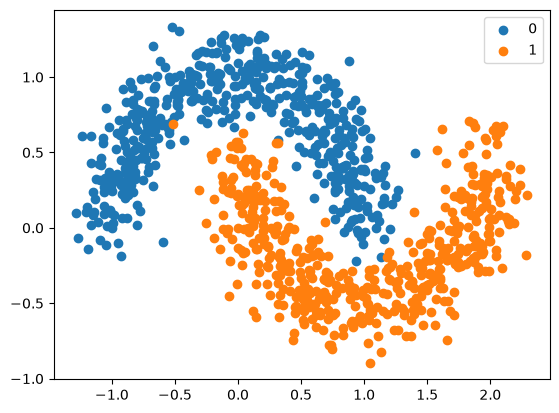

In [139]:
class ClassificationDataset(Dataset):    
    def __init__(self, n_samples: int = 1000, noise: float = 0.15):
        self.n_samples = n_samples
        self.noise = noise
        x, y = sklearn.datasets.make_moons(n_samples=n_samples, noise=noise)
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    
cls_ds_train = ClassificationDataset()
cls_ds_test = ClassificationDataset()
cls_dl_train = DataLoader(cls_ds_train, batch_size=16, shuffle=True)
cls_dl_test = DataLoader(cls_ds_test, batch_size=16, shuffle=True)

mask_0 = cls_ds_train.y == 0
plt.scatter(cls_ds_train.x[mask_0, 0], cls_ds_train.x[mask_0, 1], label='0')
plt.scatter(cls_ds_train.x[~mask_0, 0], cls_ds_train.x[~mask_0, 1], label='1')
plt.legend()

In [140]:
def plot_decision_boundary(model):
    xmin = -1.5
    xmax= 2.5
    ymin=-1
    ymax=1.5

    x_rand = torch.rand((10000, 2))
    x_rand[:, 0] * (xmax-xmin) + xmin
    x_rand[:, 1] * (ymax-ymin) + ymin

    y_rand = model.forward(x_rand)
    y_rand_cls = y_rand.argmax(1)

    mask_0 = y_rand_cls == 0
    plt.scatter(x_rand[mask_0, 0], x_rand[mask_0, 1])
    plt.scatter(x_rand[~mask_0, 0], x_rand[~mask_0, 1])

100%|██████████| 1000/1000 [00:07<00:00, 129.38it/s]


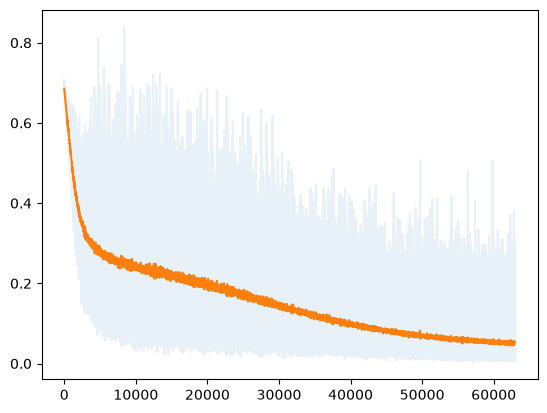

In [152]:
class ClassificationModel(nn.Module):
    def __init__(self, n_hidden_1: int = 128, n_hidden_2: int = 64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, n_hidden_1),
            nn.ReLU(),
            nn.Linear(n_hidden_1, n_hidden_2),
            nn.ReLU(),
            nn.Linear(n_hidden_2, 1)
        )
    
    def forward(self, x):
        return self.model(x)
    
model = ClassificationModel()
optim = torch.optim.SGD(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

losses = []
fig, ax = plt.subplots()
for i in tqdm(range(1000)):
    for x, y in cls_dl_train:
        
        optim.zero_grad()
        y_pred = model.forward(x).squeeze()
        y_pred = torch.sigmoid(y_pred)
        loss = loss_fn(y_pred, y)
        losses.append(loss.detach())
        loss.backward()
        optim.step()
        
rolling_avg = torch.tensor(losses).view(1, 1, -1)
rolling_avg = torch.nn.functional.avg_pool1d(rolling_avg, kernel_size=100, stride=1).view(-1)
plt.plot(losses, alpha=0.1)
plt.plot(rolling_avg)


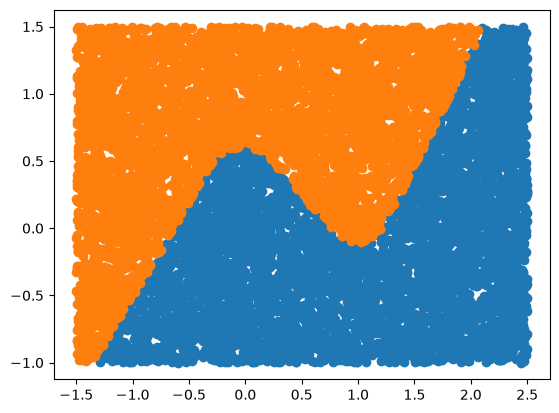

In [162]:
def plot_decision_boundary(model):
    xmin = -1.5
    xmax= 2.5
    ymin=-1
    ymax=1.5

    x_rand = torch.rand((10000, 2))
    x_rand[:, 0] = x_rand[:, 0] * (xmax-xmin) + xmin
    x_rand[:, 1] = x_rand[:, 1] * (ymax-ymin) + ymin

    y_rand = model.forward(x_rand).squeeze()

    mask_0 = torch.sigmoid(y_rand) > 0.5
    
    plt.scatter(x_rand[mask_0, 0], x_rand[mask_0, 1])
    plt.scatter(x_rand[~mask_0, 0], x_rand[~mask_0, 1])
plot_decision_boundary(model)

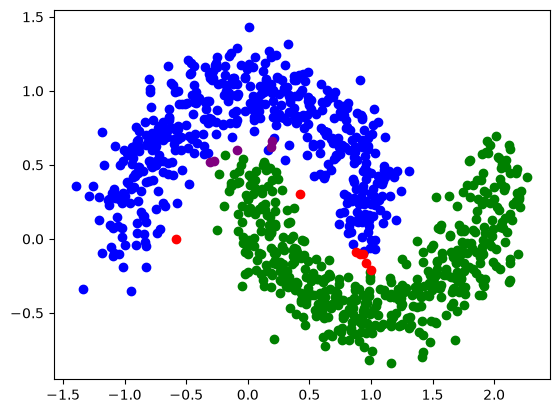

In [164]:
with torch.no_grad():
    y_pred = model.forward(cls_ds_test.x)
    y_pred_cls = torch.sigmoid(y_pred).squeeze() > 0.5
    

pred_mask_0 = y_pred_cls == 0
actual_mask_0 = cls_ds_test.y == 0

# tn
plt.scatter(cls_ds_test.x[pred_mask_0 & actual_mask_0, 0], cls_ds_test.x[pred_mask_0 & actual_mask_0, 1], label='TN', c='blue')
plt.scatter(cls_ds_test.x[pred_mask_0 & ~actual_mask_0, 0], cls_ds_test.x[pred_mask_0 & ~actual_mask_0, 1], label='FN', c='purple')
plt.scatter(cls_ds_test.x[~pred_mask_0 & ~actual_mask_0, 0], cls_ds_test.x[~pred_mask_0 & ~actual_mask_0, 1], label='TP', c='green')
plt.scatter(cls_ds_test.x[~pred_mask_0 & actual_mask_0, 0], cls_ds_test.x[~pred_mask_0 & actual_mask_0, 1], label='FP', c='red')
